Dataset Shape: (10000, 17)

Missing Values:
Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Category         0
Sub_Category     0
Product_Name     0
Region           0
State            0
City             0
Quantity         0
Sales            0
Discount         0
Cost             0
Profit           0
Payment_Mode     0
Sales_Channel    0
dtype: int64

========== SALES KPIs ==========
Total Sales      : 1092807729.66
Total Profit     : 213993703.62
Total Orders     : 10000
Total Quantity   : 30241
Profit Margin    : 19.58 %

========== CATEGORY SALES ==========
Category
Electronics       2.221649e+08
Sports            2.199045e+08
Furniture         2.182688e+08
Clothing          2.178122e+08
Home & Kitchen    2.146574e+08
Name: Sales, dtype: float64


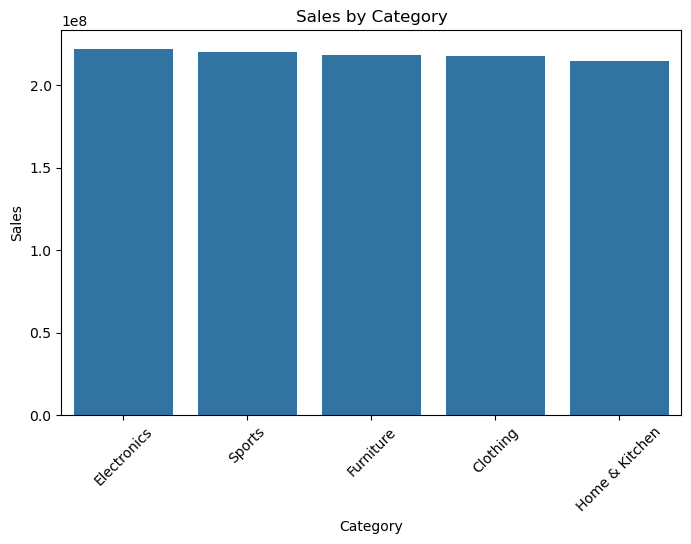


========== MONTHLY SALES ==========
Order_Date
2025-01    8.862158e+07
2025-02    8.492921e+07
2025-03    1.001925e+08
2025-04    9.483269e+07
2025-05    8.606757e+07
2025-06    9.093054e+07
2025-07    8.701946e+07
2025-08    8.908307e+07
2025-09    9.008019e+07
2025-10    9.662522e+07
2025-11    8.783994e+07
2025-12    9.658578e+07
Freq: M, Name: Sales, dtype: float64


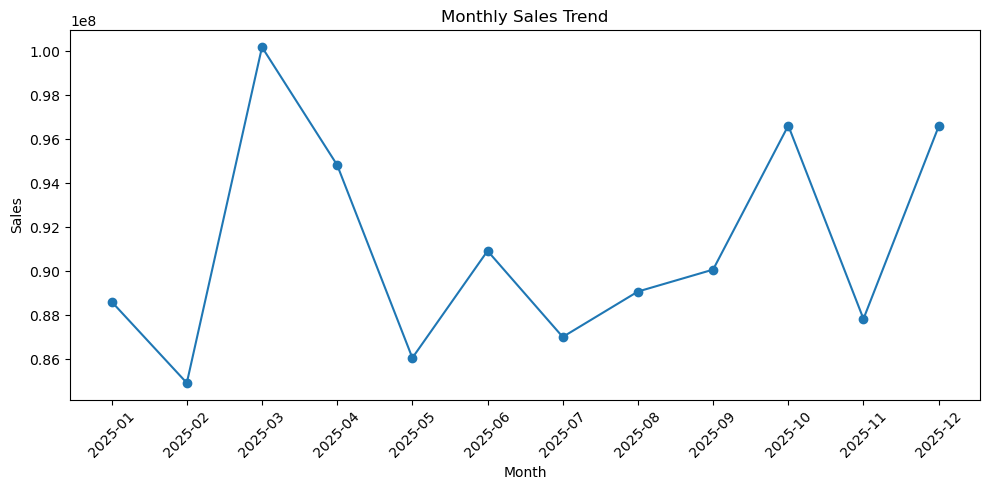


========== TOP 10 PRODUCTS ==========
Product_Name
Mobile            49015658.03
Vacuum Cleaner    48109261.10
Jeans             47292761.27
Cricket Bat       46217941.14
Tablet            45826181.02
Tennis Racket     45792463.55
Mixer             45512454.77
Running Shoes     45260850.11
Jacket            45075742.97
Desk              44681057.60
Name: Sales, dtype: float64


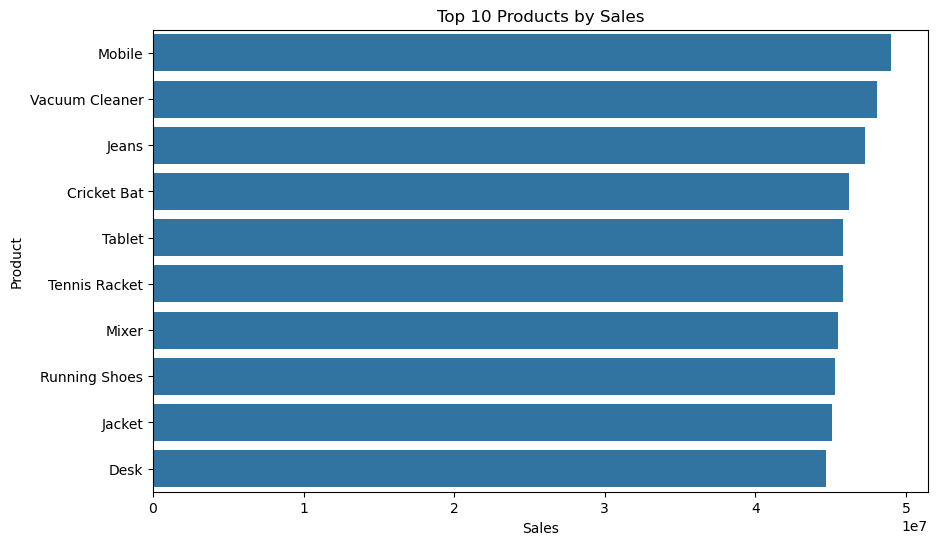


========== REGION SALES ==========
Region
North    5.436180e+08
South    2.252748e+08
West     2.104744e+08
East     1.134406e+08
Name: Sales, dtype: float64


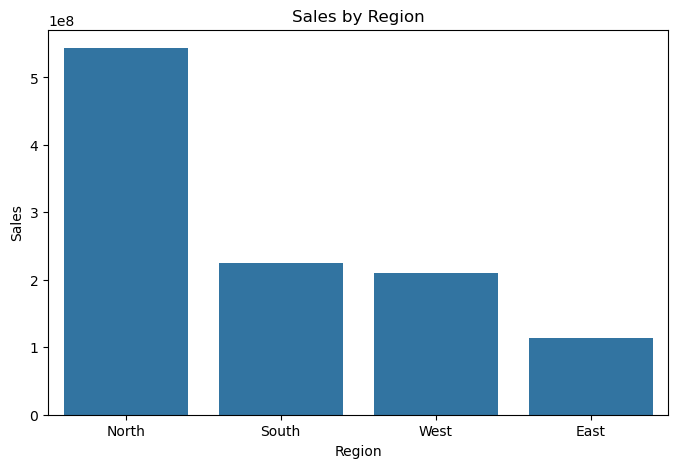


========== TOP 10 STATES ==========
State
Uttar Pradesh    1.144669e+08
West Bengal      1.134406e+08
Karnataka        1.129625e+08
Tamil Nadu       1.123123e+08
Rajasthan        1.121757e+08
Punjab           1.098179e+08
Gujarat          1.067198e+08
Delhi            1.045748e+08
Maharashtra      1.037546e+08
Haryana          1.025827e+08
Name: Sales, dtype: float64


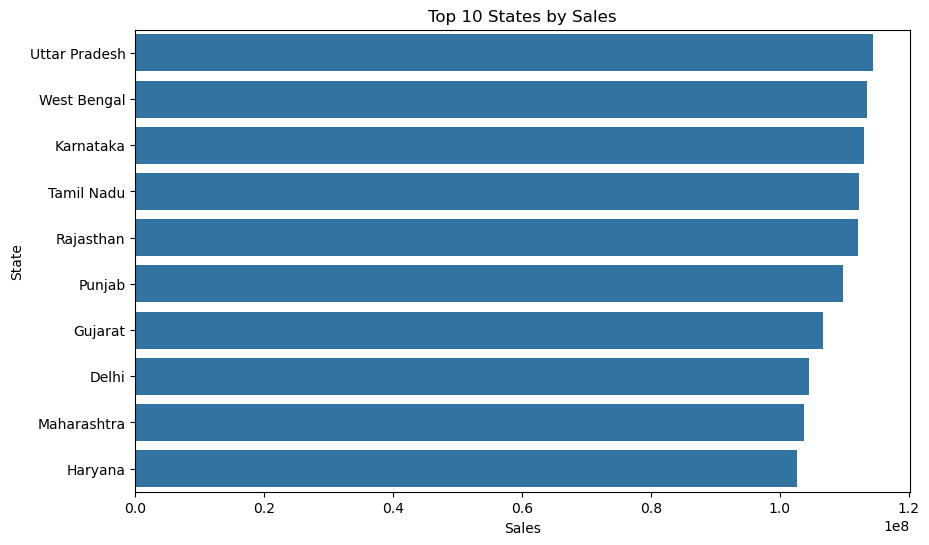

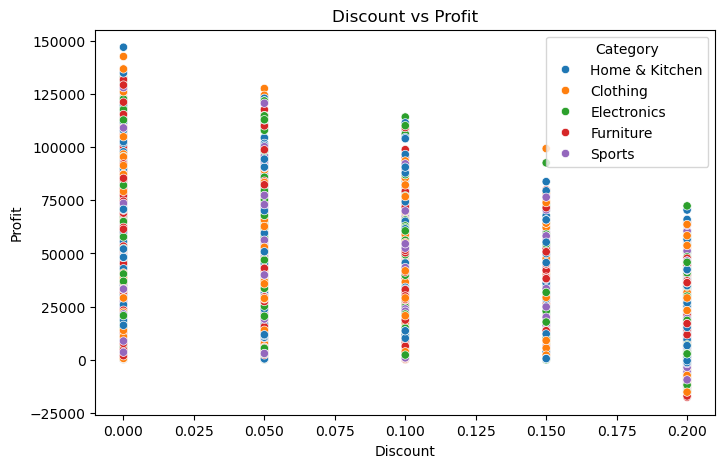


========== BUSINESS INSIGHTS ==========
Best Category : Electronics
Best Product  : Mobile
Best Region   : North
Best State    : Uttar Pradesh
Best Month    : 2025-03

Project Analysis Completed Successfully!


In [5]:
# SALES PERFORMANCE ANALYSIS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
df = pd.read_csv("C:\\Users\\hp\\Downloads\\sales_data.csv")

# Basic Information
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

# Remove Duplicates
df = df.drop_duplicates()

# Convert Date
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Create Month and Year
df["Month"] = df["Order_Date"].dt.month
df["Year"] = df["Order_Date"].dt.year

# =========================
# KPIs
# =========================

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
total_quantity = df["Quantity"].sum()
profit_margin = (total_profit / total_sales) * 100

print("\n========== SALES KPIs ==========")
print("Total Sales      :", round(total_sales, 2))
print("Total Profit     :", round(total_profit, 2))
print("Total Orders     :", total_orders)
print("Total Quantity   :", total_quantity)
print("Profit Margin    :", round(profit_margin, 2), "%")

# =========================
# Category Analysis
# =========================

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print("\n========== CATEGORY SALES ==========")
print(category_sales)

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# =========================
# Monthly Sales
# =========================

monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Sales"].sum()

print("\n========== MONTHLY SALES ==========")
print(monthly_sales)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# Top 10 Products
# =========================

top_products = (
    df.groupby("Product_Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\n========== TOP 10 PRODUCTS ==========")
print(top_products)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

# =========================
# Region Analysis
# =========================

region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\n========== REGION SALES ==========")
print(region_sales)

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

# =========================
# State Analysis
# =========================

state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\n========== TOP 10 STATES ==========")
print(state_sales)

plt.figure(figsize=(10,6))
sns.barplot(x=state_sales.values, y=state_sales.index)
plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")
plt.show()

# =========================
# Discount vs Profit
# =========================

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Category"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

# =========================
# Final Business Insights
# =========================

best_category = category_sales.idxmax()
best_product = top_products.idxmax()
best_region = region_sales.idxmax()
best_state = state_sales.idxmax()
best_month = monthly_sales.idxmax()

print("\n========== BUSINESS INSIGHTS ==========")
print("Best Category :", best_category)
print("Best Product  :", best_product)
print("Best Region   :", best_region)
print("Best State    :", best_state)
print("Best Month    :", best_month)

print("\nProject Analysis Completed Successfully!")